In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [1]:
import pandas as pd 
import numpy as np
from tensorflow.keras import utils # utils.to_categorical()
from tensorflow.keras import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# 로지스틱회귀분석(이진분류)
## 1. 데이터 셋 생성 및 전처리

In [2]:
# 1. csv파일을 데이터프레임으로 읽어오기(결측치처리, 균형확인 용어) => 넘파이배열로 변환 => 데이터분할
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)
df

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.shape

(768, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.isna().sum()

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

In [6]:
df[8].value_counts()/len(df)

0    0.651042
1    0.348958
Name: 8, dtype: float64

In [7]:
# np.array(df)
dataset = df.values
dataset = df.to_numpy()

In [8]:
# 2. csv파일을 넘파이배열 읽어오기 => 데이터 분할
    # np.loadtxt()
dataset = np.loadtxt('data/pima-indians-diabetes.csv', 
                     encoding='utf-8',
                     delimiter=',')
dataset.shape

(768, 9)

In [21]:
# 데이터 분할 : 학습데이터셋(모델학습용) + 시험데이터셋(모델평가용)
X_train = dataset[:620, :-1]
y_train = dataset[:620, -1]
X_test  = dataset[620:, :-1]
y_test  = dataset[620:, -1]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((620, 8), (620,), (148, 8), (148,))

## 2. 모델 구성

In [22]:
model = Sequential()
# model.add(Dense(64, input_shape=(8,), activation='relu'))
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='elu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 32)                288       
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 dense_8 (Dense)             (None, 1)                 17        
                                                                 
Total params: 833
Trainable params: 833
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [23]:
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])
# accuracy가 자동적으로 binary_accuracy 적용
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

## 4. 학습

In [24]:
%%time
hist = model.fit(X_train, y_train, # 훈련(학습)데이터셋
                epochs=200,
                batch_size=310,
                # validation_data=(X_val, y_val)  검증데이터셋
                validation_split=0.1, # 검증데이터비율(훈련데이터셋에서 10%는 검증데이터셋으로) 
                verbose=0) # 학습과정 로그 출력 안 함

CPU times: total: 9.89 s
Wall time: 8.41 s


## 5. 모델 평가하기
- 학습과정 시각화하여 살펴보기
- 평가(시험데이터셋)
- 교차표 (혼돈매트릭스, 성능평가지표) 그리기

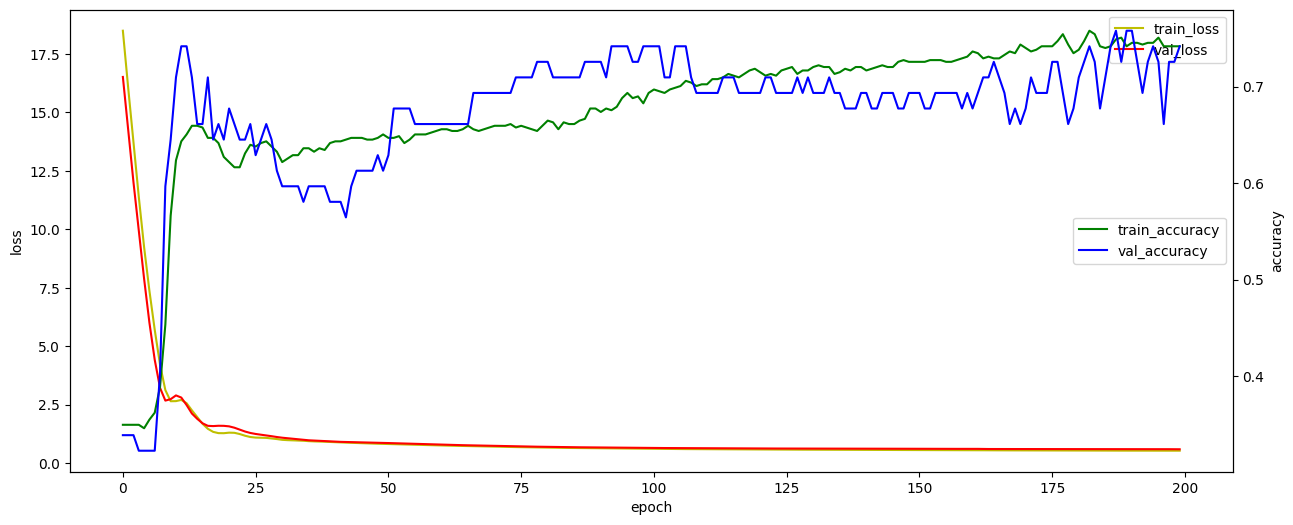

In [25]:
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [26]:
# 모델 평가(X)
model.evaluate(X_train, y_train, 
              # batch_size=310
              )

20/20 [==============================] - 0s 2ms/step - loss: 0.5349 - accuracy: 0.7500


[0.5349075794219971, 0.75]

In [29]:
# 모델 평가(O)
loss, accuracy = model.evaluate(X_test, y_test)

5/5 [==============================] - 0s 2ms/step - loss: 0.6308 - accuracy: 0.6486


In [30]:
# 교차표(혼동행렬, 성능평가지표)
y_hat = (model.predict(X_test)>0.5).astype(int)

5/5 [==============================] - 0s 2ms/step


In [32]:
TN=0; FP=0; FN=0; TP=0
for y, h in zip(y_test, y_hat.reshape(-1)):
    if y==0 and h==0:
        TN += 1
    elif y==0 and h==1:
        FP += 1
    elif y==1 and h==0:
        FN += 1
    else:
        TP += 1
print(TN, FP)
print(FN, TP)

79 17
35 17


In [43]:
ctab = pd.crosstab(y_test.astype(int),
           y_hat.reshape(-1))
ctab.index.name = '실제값'
ctab.columns.name = '예측값'
pd.crosstab(y_test.astype(int),
            y_hat.reshape(-1),
            rownames=['실제값'],
            colnames=['예측값']) # 결과가 데이터프레임

예측값,0,1
실제값,,
0,79,17
1,35,17


In [45]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat) # 결과가 numpy 배열인 홍동행렬

array([[79, 17],
       [35, 17]], dtype=int64)

In [46]:
precision = 26 / (15+26)
recall = 26 / (26+26)
print('recall : ', recall)
print('precision : ',precision)

recall :  0.5
precision :  0.6341463414634146


## 6.모델 사용(예측,저장)

In [51]:
# 모델 저장
from tensorflow.keras.models import save_model, load_model
model.save('model/05_pima.h5')
save_model(model, 'model/05_pima.h5')

In [52]:
# 저장한 모델 load
model2 = load_model('model/05_pima.h5')

In [53]:
X_test[0]

array([  2.   , 112.   ,  86.   ,  42.   , 160.   ,  38.4  ,   0.246,
        28.   ])

In [55]:
# 예측하기
(model.predict([[2,112,86,42,160,38.4,0.246,28]])>0.5).astype(int)

1/1 [==============================] - 0s 57ms/step


array([[0]])

# 분류분석
- 1. 데이터 생성 및 전처리 : 훈련셋600, 검증셋100, 테스트셋68로 분리. 타겟변수의 원핫인코딩
- 2. 모델 생성(input8, output1)- 출력층의 활성화함수 softmax
- 3. 모델학습과정 loss='catrgorical_crossentropy' metrics=['accuracy']
- 4. 모델학습 validation_data = (X_val, y_val)
- 5. 모델학습평가
- 6. 모델사용 mode;.predict(input_data).argmax()
## 1. 데이터셋 생성 및 전처리

In [58]:
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)
dataset = df.values

In [71]:
# 훈련셋600, 검증셋100, 테스트셋68
X_train = dataset[:600, :-1]
y_train = dataset[:600, -1]
X_val   = dataset[600:700, :-1]
y_val   = dataset[600:700, -1]
X_test  = dataset[700:, :-1]
y_test  = dataset[700:, -1]
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((600, 8), (600,), (100, 8), (100,), (68, 8), (68,))

In [76]:
# 원핫인코딩 ( 0 : 1 0 / 1 : 0 1 )
Y_train = utils.to_categorical(y_train, num_classes=2)
Y_val   = utils.to_categorical(y_val, 2)
Y_test  = utils.to_categorical(y_test)
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

((600, 8), (600, 2), (100, 8), (100, 2), (68, 8), (68, 2))

## 2. 모델생성 (input8 -> target2)

In [77]:
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=2, activation='softmax'))
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_21 (Dense)            (None, 32)                288       
                                                                 
 dense_22 (Dense)            (None, 64)                2112      
                                                                 
 dense_23 (Dense)            (None, 16)                1040      
                                                                 
 dense_24 (Dense)            (None, 2)                 34        
                                                                 
Total params: 3,474
Trainable params: 3,474
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [78]:
model.compile(loss='categorical_crossentropy',
              optimizer='nadam',
              metrics=['accuracy'])

## 4. 모델 학습

In [79]:
hist = model.fit(X_train, Y_train,
                 epochs=200,
                 validation_data=(X_val, Y_val),
                 verbose=1)

Epoch 1/200
19/19 [==============================] - 2s 13ms/step - loss: 1.9325 - accuracy: 0.5633 - val_loss: 0.8964 - val_accuracy: 0.6200
Epoch 2/200
19/19 [==============================] - 0s 4ms/step - loss: 1.0290 - accuracy: 0.6000 - val_loss: 1.1355 - val_accuracy: 0.4800
Epoch 3/200
19/19 [==============================] - 0s 4ms/step - loss: 0.8961 - accuracy: 0.6250 - val_loss: 0.7430 - val_accuracy: 0.7400
Epoch 4/200
19/19 [==============================] - 0s 4ms/step - loss: 0.9268 - accuracy: 0.6100 - val_loss: 0.8134 - val_accuracy: 0.7000
Epoch 5/200
19/19 [==============================] - 0s 3ms/step - loss: 0.7197 - accuracy: 0.6717 - val_loss: 0.7455 - val_accuracy: 0.6000
Epoch 6/200
19/19 [==============================] - 0s 3ms/step - loss: 0.7024 - accuracy: 0.6600 - val_loss: 1.3047 - val_accuracy: 0.4600
Epoch 7/200
19/19 [==============================] - 0s 4ms/step - loss: 0.6877 - accuracy: 0.6767 - val_loss: 0.7717 - val_accuracy: 0.7000
Epoch 8/200


Epoch 59/200
19/19 [==============================] - 0s 5ms/step - loss: 0.4475 - accuracy: 0.7767 - val_loss: 0.7239 - val_accuracy: 0.6400
Epoch 60/200
19/19 [==============================] - 0s 4ms/step - loss: 0.5084 - accuracy: 0.7717 - val_loss: 0.5764 - val_accuracy: 0.7500
Epoch 61/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4579 - accuracy: 0.7800 - val_loss: 0.8718 - val_accuracy: 0.7000
Epoch 62/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4808 - accuracy: 0.7617 - val_loss: 0.4753 - val_accuracy: 0.8100
Epoch 63/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4541 - accuracy: 0.7917 - val_loss: 0.5237 - val_accuracy: 0.7800
Epoch 64/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4521 - accuracy: 0.7667 - val_loss: 0.6156 - val_accuracy: 0.7400
Epoch 65/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4289 - accuracy: 0.7983 - val_loss: 0.5173 - val_accuracy: 0.7500
Epoch 

19/19 [==============================] - 0s 4ms/step - loss: 0.4342 - accuracy: 0.7817 - val_loss: 0.6115 - val_accuracy: 0.7400
Epoch 117/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4278 - accuracy: 0.8117 - val_loss: 0.5035 - val_accuracy: 0.8000
Epoch 118/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3911 - accuracy: 0.8067 - val_loss: 0.5738 - val_accuracy: 0.7400
Epoch 119/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4073 - accuracy: 0.8067 - val_loss: 0.5344 - val_accuracy: 0.7800
Epoch 120/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4433 - accuracy: 0.8017 - val_loss: 0.5484 - val_accuracy: 0.8000
Epoch 121/200
19/19 [==============================] - 0s 3ms/step - loss: 0.3834 - accuracy: 0.8200 - val_loss: 0.5293 - val_accuracy: 0.7700
Epoch 122/200
19/19 [==============================] - 0s 5ms/step - loss: 0.3982 - accuracy: 0.8167 - val_loss: 0.5374 - val_accuracy: 0.7800
Epoch 123/200

19/19 [==============================] - 0s 4ms/step - loss: 0.3507 - accuracy: 0.8433 - val_loss: 0.5744 - val_accuracy: 0.7500
Epoch 174/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3554 - accuracy: 0.8283 - val_loss: 0.5594 - val_accuracy: 0.7700
Epoch 175/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3525 - accuracy: 0.8367 - val_loss: 0.5530 - val_accuracy: 0.7700
Epoch 176/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3494 - accuracy: 0.8567 - val_loss: 0.6098 - val_accuracy: 0.7900
Epoch 177/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3479 - accuracy: 0.8300 - val_loss: 0.5446 - val_accuracy: 0.7800
Epoch 178/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3483 - accuracy: 0.8317 - val_loss: 0.6746 - val_accuracy: 0.6900
Epoch 179/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3656 - accuracy: 0.8250 - val_loss: 0.5886 - val_accuracy: 0.7500
Epoch 180/200

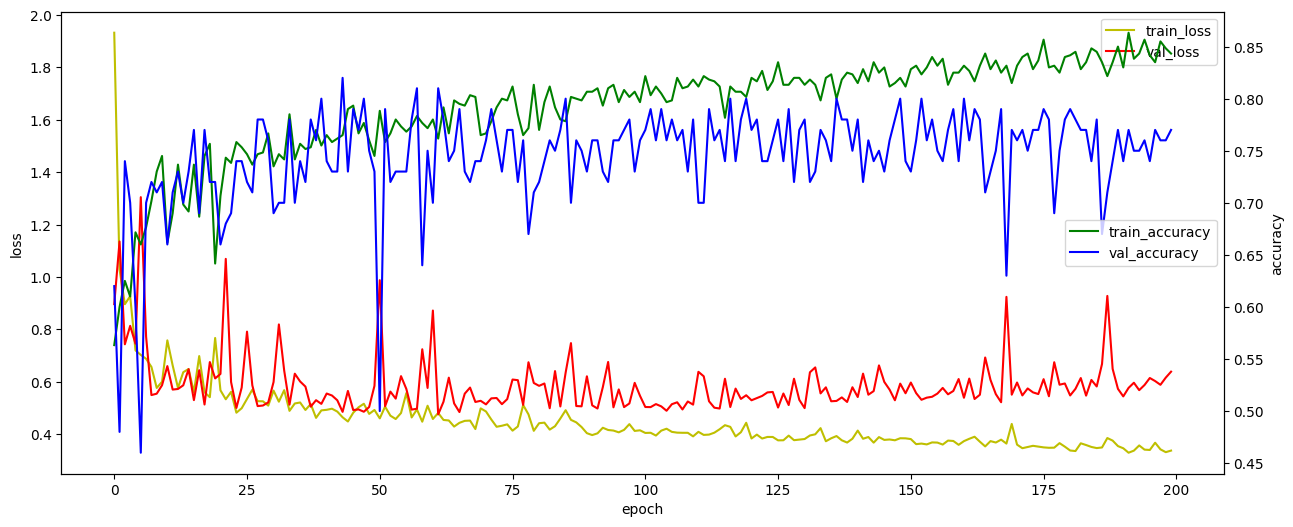

In [80]:
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [81]:
# 모델 평가
loss, accuracy = model.evaluate(X_test, Y_test)
accuracy

3/3 [==============================] - 0s 4ms/step - loss: 0.6394 - accuracy: 0.7500


0.75

In [84]:
# 혼동행렬==교차표를 위한 y_test의 예측값
y_hat = model.predict(X_test).argmax(axis=1)
y_hat.shape, y_test.shape

3/3 [==============================] - 0s 2ms/step


((68,), (68,))

In [85]:
# 교차표
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0.0,37,4
1.0,13,14


In [86]:
# 혼동행렬
confusion_matrix(y_test, y_hat)

array([[37,  4],
       [13, 14]], dtype=int64)

## 6. 모델 사용(예측)

In [88]:
print(X_test[0])

[  2.    122.     76.     27.    200.     35.9     0.483  26.   ]


In [90]:
model.predict([[2,122,76,27,200,35.9,0.483,26]]).argmax(axis=1)

1/1 [==============================] - 0s 40ms/step


array([0], dtype=int64)